<a id="time_analysis"></a>
## Extended Time Analysis

This section provides comprehensive time-based analysis of article distribution patterns and trends.

### Contents:
* [Overall Time Distribution](#overall_time_enhanced)
* [Time Distribution by Publisher](#time_by_publisher)  
* [Time Distribution by Section](#time_by_section)
* [Average Article Length Over Time](#length_over_time)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

In [9]:
df_articles = pd.read_pickle("../data/cleaned/cleaned_articles.pkl")
df_articles.head()

,title,publisher,date,section,body,source_file
0,"Under a Highway in Rio, a Dance Style Charms a...",New York Times,2024-12-31,WORLD; americas,"Trucks, buses and cars rumbled overhead, drown...",NYT/1.DOCX
1,These were the big stories in arts and culture...,Other publisher,2024-12-31,WHAT TO KNOW,The arts in Dayton continued to thrive in 2024...,Other publishers/Files (500) (1).DOCX
2,She Exalted The Beauty Of Dance,New York Times,2024-12-31,Section C; Column 0; The Arts/Cultural Desk; P...,She was The New Yorker's first dance critic. H...,NYT/1.DOCX
3,A Well-Documented Childhood. A Very Private Life.,New York Times,2024-12-31,Section A; Column 0; National Desk; Pg. 16,Jimmy Carter's daughter had an extraordinary a...,NYT/1.DOCX
4,"Congressional pay, minimum wage stagnant for y...",Other publisher,2024-12-31,OPINION; Pg. A13,ABSTRACT\nMembers of Congress have not seen a ...,Other publishers/Files (500) (1).DOCX


In [12]:
print("Available columns:", df_articles.columns.tolist())

Available columns: ['title', 'publisher', 'date', 'section', 'body', 'source_file', 'date_parsed', 'year', 'month', 'year_month']


In [13]:
# Create word count from body text
def count_words_from_body(text):
    """Count words in the body text"""
    if pd.isna(text):
        return 0
    return len(str(text).split())

df_articles['word_count'] = df_articles['body'].apply(count_words_from_body)

# Get publisher counts
publisher_counts = df_articles['publisher'].value_counts()
print("\nPublisher distribution:")
for pub, count in publisher_counts.items():
    print(f"  {pub}: {count:,} articles")


Publisher distribution:
  New York Times: 26,809 articles
  Other publisher: 14,485 articles


<a id="overall_time_enhanced"></a>
### Overall Time Distribution

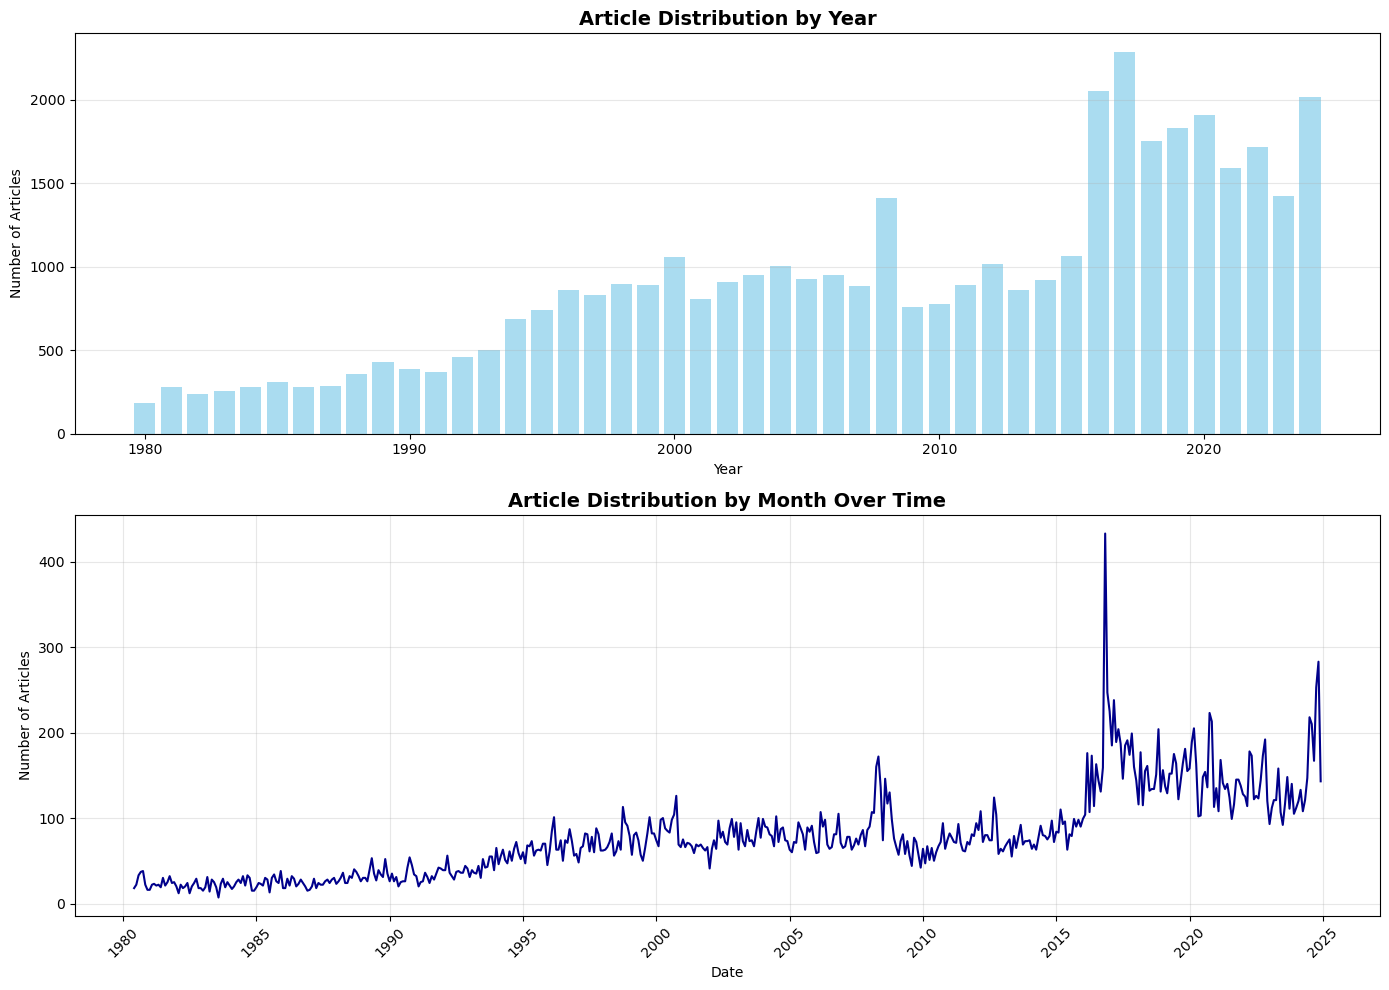

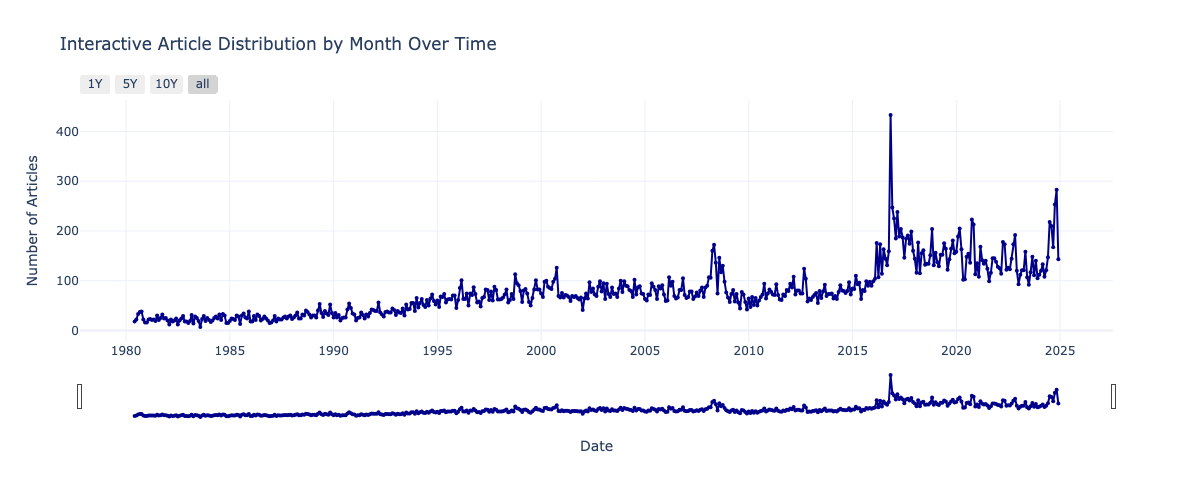

Total articles: 41,294
Date range: 1980-06-01 to 2024-12-31
Average articles per year: 917.6


In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

yearly_counts = df_articles['year'].value_counts().sort_index()
ax1.bar(yearly_counts.index, yearly_counts.values, color='skyblue', alpha=0.7)
ax1.set_title('Article Distribution by Year', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Articles')
ax1.grid(axis='y', alpha=0.3)

monthly_counts = df_articles.groupby('year_month').size()
ax2.plot(monthly_counts.index.to_timestamp(), monthly_counts.values, color='darkblue', linewidth=1.5)
ax2.set_title('Article Distribution by Month Over Time', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Number of Articles')
ax2.grid(alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


monthly_counts = df_articles.groupby('year_month').size()
monthly_df = pd.DataFrame({
    'Date': monthly_counts.index.to_timestamp(),
    'Article_Count': monthly_counts.values
})

fig_interactive = go.Figure()

fig_interactive.add_trace(go.Scatter(
    x=monthly_df['Date'],
    y=monthly_df['Article_Count'],
    mode='lines+markers',
    name='Articles per Month',
    line=dict(color='darkblue', width=2),
    marker=dict(size=4),
    hovertemplate='<b>Date:</b> %{x|%Y-%m}<br>' +
                  '<b>Articles:</b> %{y}<br>' +
                  '<extra></extra>'
))

fig_interactive.update_layout(
    title='Interactive Article Distribution by Month Over Time',
    xaxis_title='Date',
    yaxis_title='Number of Articles',
    hovermode='x unified',
    showlegend=False,
    width=900,
    height=500,
    template='plotly_white'
)

fig_interactive.update_layout(
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=1, label="1Y", step="year", stepmode="backward"),
                dict(count=5, label="5Y", step="year", stepmode="backward"),
                dict(count=10, label="10Y", step="year", stepmode="backward"),
                dict(step="all")
            ])
        ),
        rangeslider=dict(visible=True),
        type="date"
    )
)

fig_interactive.show()

print(f"Total articles: {len(df_articles):,}")
print(f"Date range: {df_articles['date'].min()} to {df_articles['date'].max()}")
print(f"Average articles per year: {len(df_articles) / len(yearly_counts):.1f}")

<a id="time_by_publisher"></a>
### Time Distribution by Publishe


------------------------------------------------------------
ARTICLE DISTRIBUTION BY PUBLISHER OVER TIME
------------------------------------------------------------


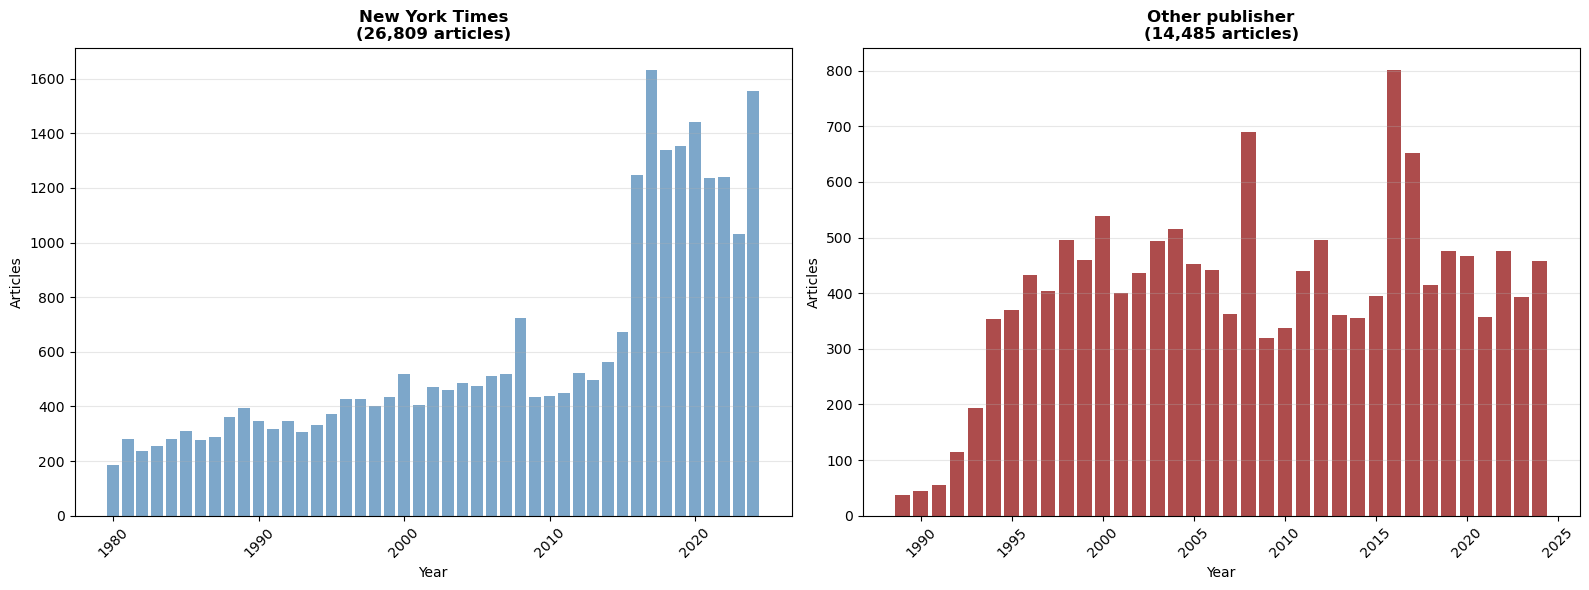

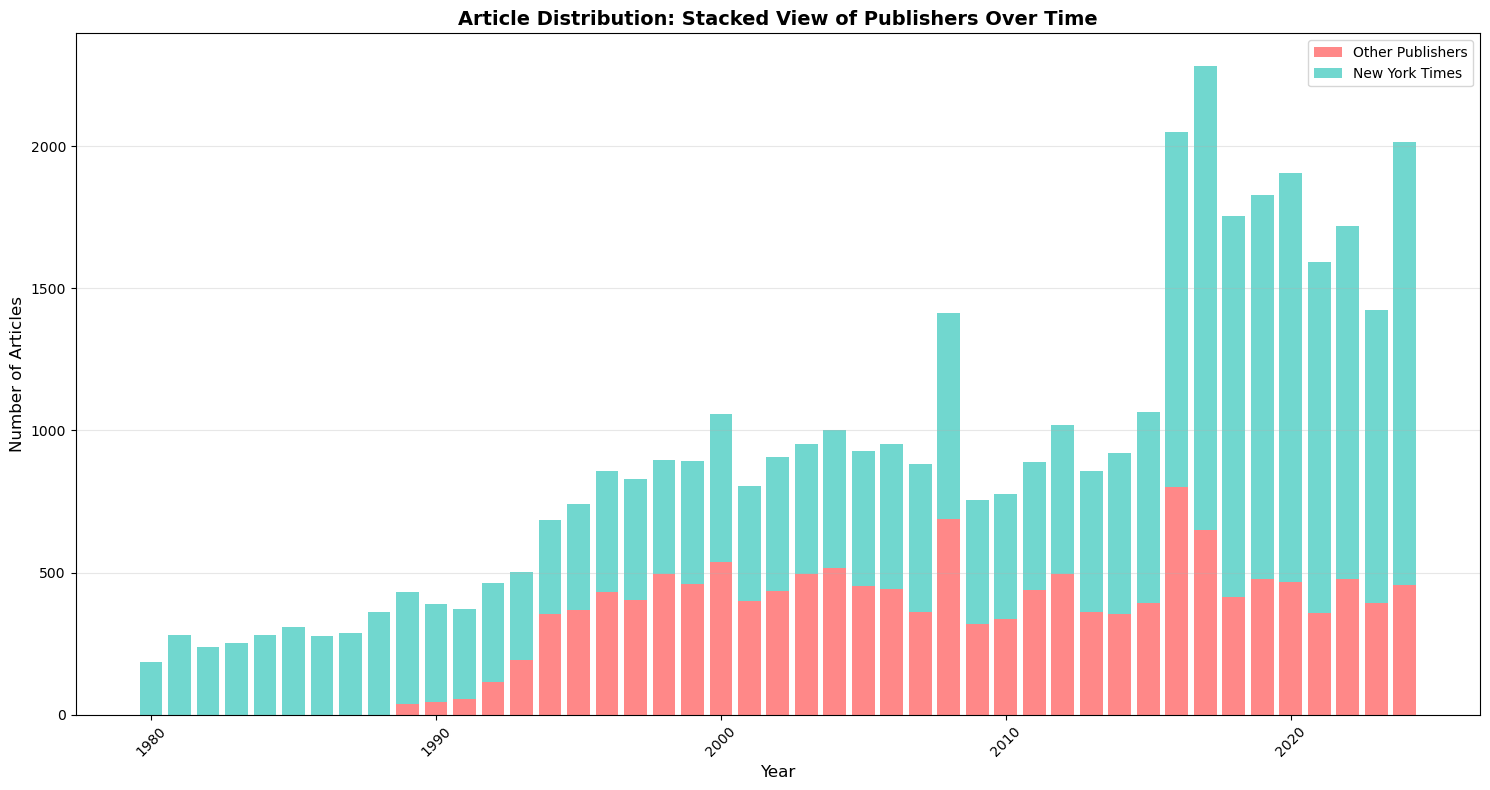

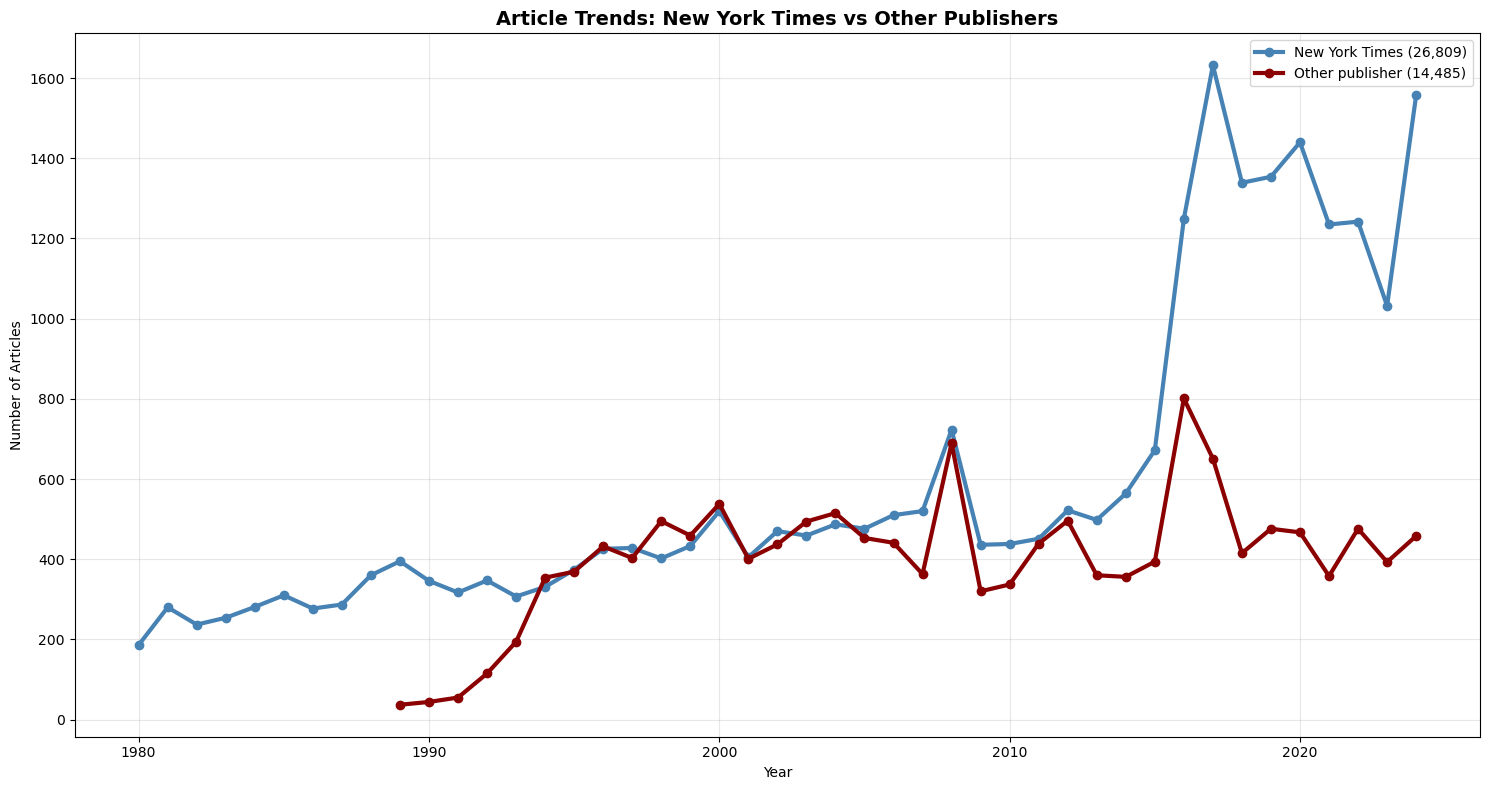

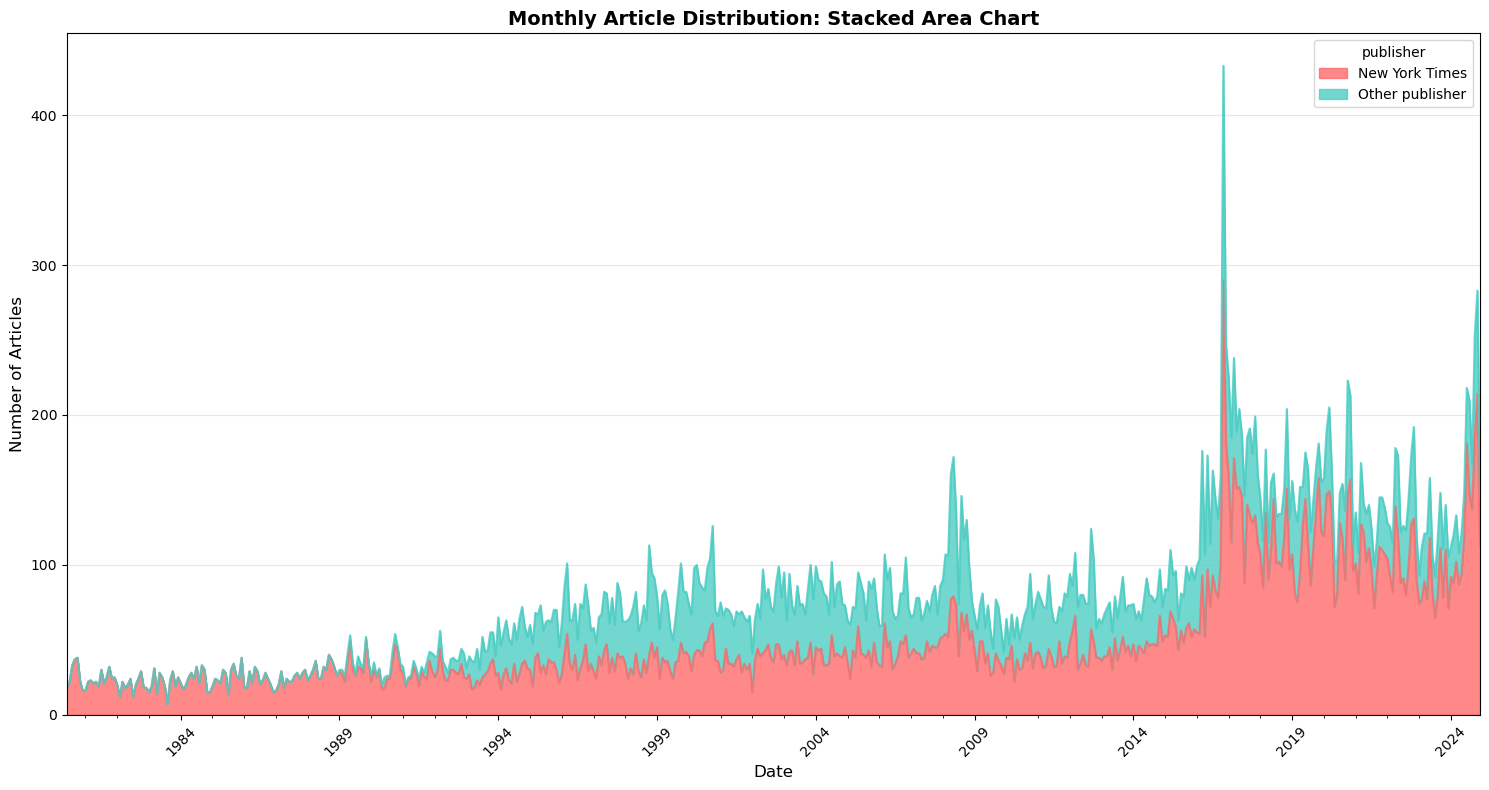

In [23]:
print(f"\n{'-'*60}")
print("ARTICLE DISTRIBUTION BY PUBLISHER OVER TIME")
print(f"{'-'*60}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['steelblue', 'darkred']
publishers = publisher_counts.index.tolist()

for i, publisher in enumerate(publishers):
    publisher_data = df_articles[df_articles['publisher'] == publisher]
    yearly_pub_counts = publisher_data['year'].value_counts().sort_index()
    
    axes[i].bar(yearly_pub_counts.index, yearly_pub_counts.values, 
               color=colors[i], alpha=0.7)
    axes[i].set_title(f'{publisher}\n({publisher_counts[publisher]:,} articles)', 
                     fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Articles')
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(15, 8))

nyt_data = df_articles[df_articles['publisher'] == 'New York Times']
other_data = df_articles[df_articles['publisher'] == 'Other publisher']

nyt_yearly = nyt_data['year'].value_counts().sort_index()
other_yearly = other_data['year'].value_counts().sort_index()

all_years = sorted(set(nyt_yearly.index) | set(other_yearly.index))
nyt_counts = [nyt_yearly.get(year, 0) for year in all_years]
other_counts = [other_yearly.get(year, 0) for year in all_years]

width = 0.8
ax.bar(all_years, other_counts, width, label='Other Publishers', 
       color='#FF6B6B', alpha=0.8) 
ax.bar(all_years, nyt_counts, width, bottom=other_counts, 
       label='New York Times', color='#4ECDC4', alpha=0.8) 

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Articles', fontsize=12)
ax.set_title('Article Distribution: Stacked View of Publishers Over Time', 
             fontsize=14, fontweight='bold')

ax.legend(loc='upper right')

ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 8))
for i, publisher in enumerate(publishers):
    publisher_data = df_articles[df_articles['publisher'] == publisher]
    yearly_pub_counts = publisher_data['year'].value_counts().sort_index()
    
    plt.plot(yearly_pub_counts.index, yearly_pub_counts.values, 
             marker='o', linewidth=3, label=f'{publisher} ({publisher_counts[publisher]:,})', 
             color=colors[i])

plt.title('Article Trends: New York Times vs Other Publishers', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Articles')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(15, 8))

monthly_data = df_articles.groupby(['year_month', 'publisher']).size().unstack(fill_value=0)

monthly_data.plot(kind='area', stacked=True, 
                 color=['#FF6B6B', '#4ECDC4'], 
                 alpha=0.8, ax=ax)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Articles', fontsize=12)
ax.set_title('Monthly Article Distribution: Stacked Area Chart', 
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<a id="time_by_section"></a>
### Time Distribution by Section


------------------------------------------------------------
ARTICLE DISTRIBUTION BY SECTION OVER TIME
------------------------------------------------------------

Top 10 sections by article count:
  OPINION: 1,368 articles
  US; politics: 1,028 articles
  Section A; Column 0; National Desk; Pg. 1: 602 articles
  NYREGION: 439 articles
  US: 352 articles
  WORLD; europe: 345 articles
  MOVIES: 335 articles
  BOOKS; review: 324 articles
  NEWS; Pg. 1A: 285 articles
  NEWS;: 223 articles
Other sections (not in top 10): 35,993 articles (87.2%)
Total unique sections: 12399


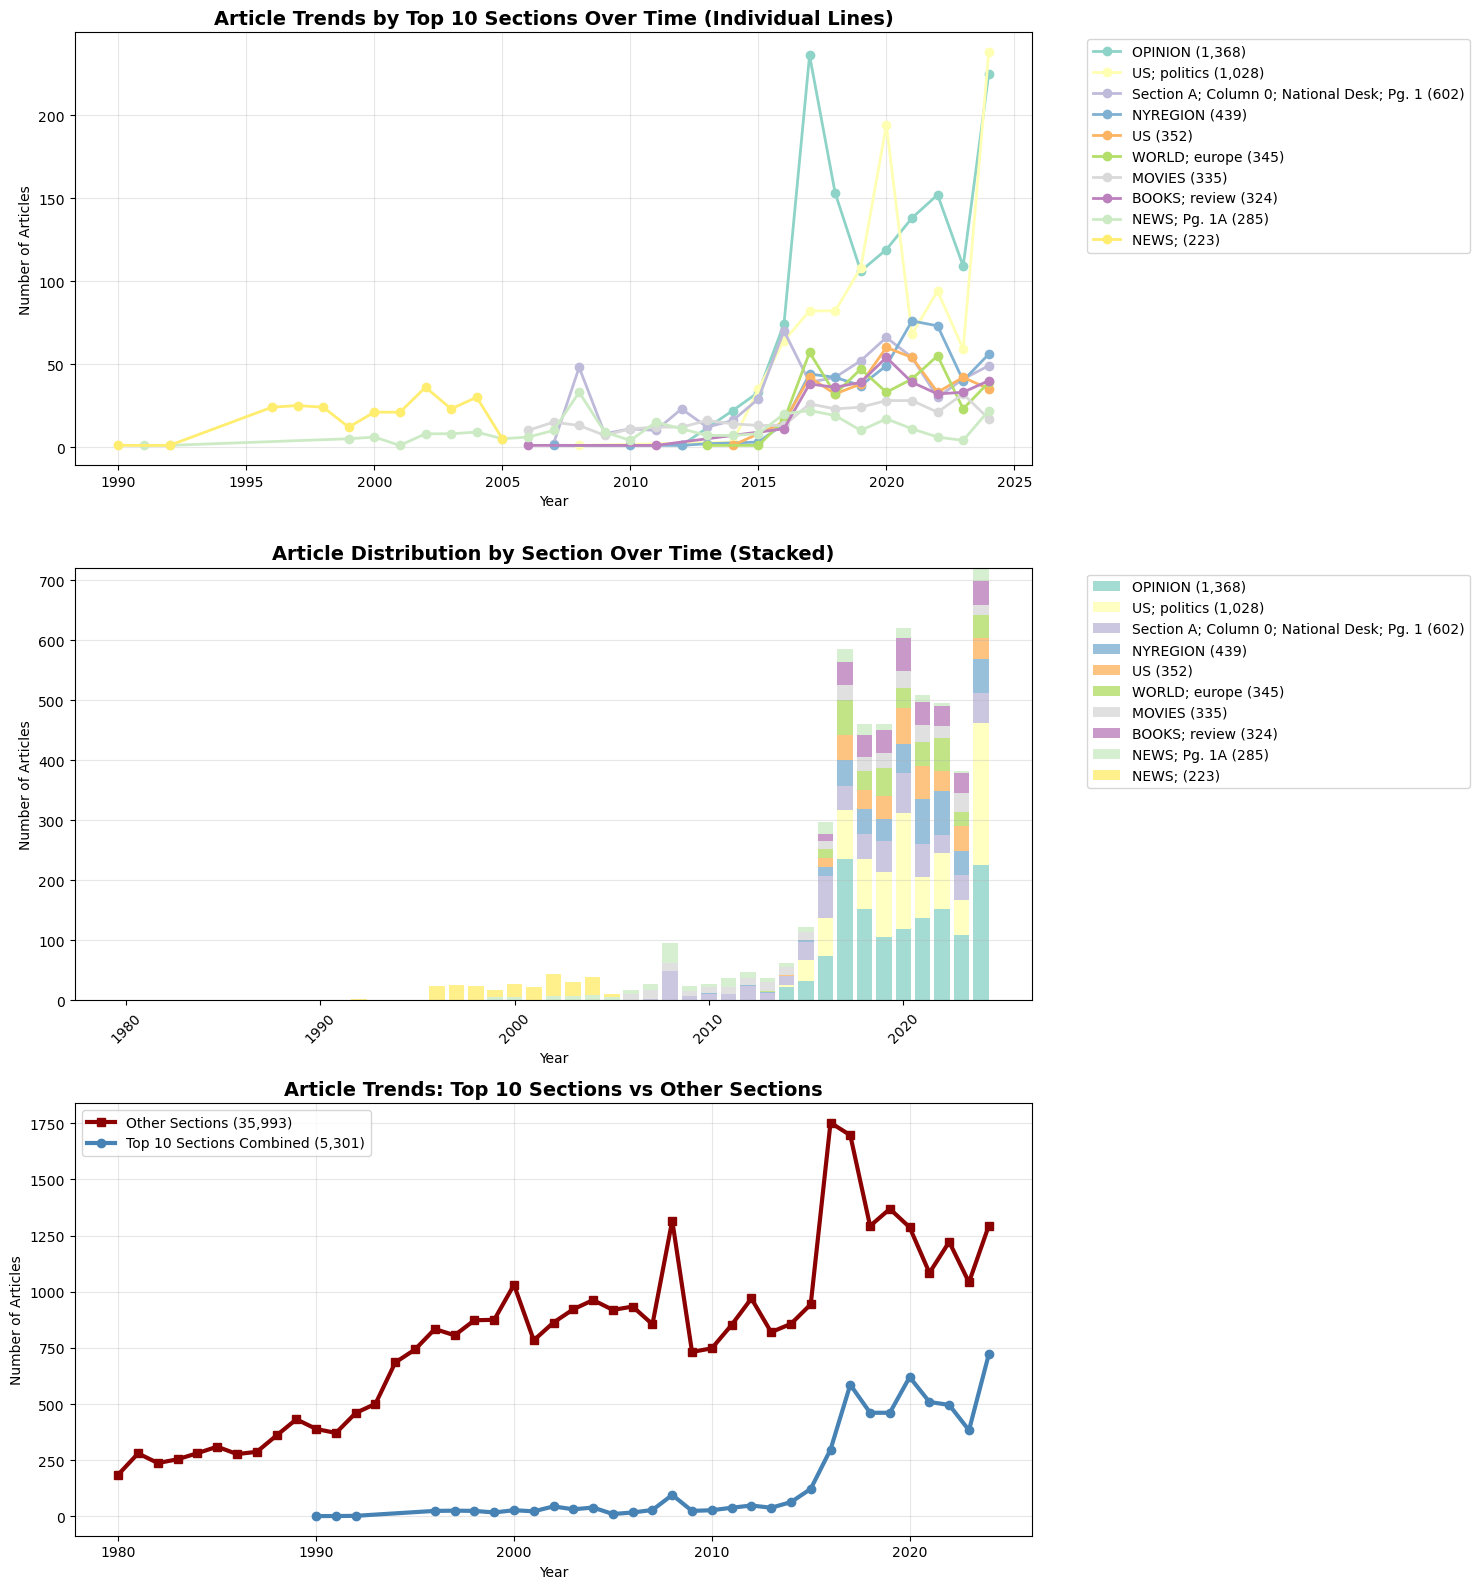

In [40]:
print(f"\n{'-'*60}")
print("ARTICLE DISTRIBUTION BY SECTION OVER TIME")
print(f"{'-'*60}")

# Prepare section data (do this once)
top_sections = df_articles['section'].value_counts().head(10)
print(f"\nTop {len(top_sections)} sections by article count:")
for section, count in top_sections.items():
    print(f"  {section}: {count:,} articles")

# Calculate "Other sections" data
top_section_names = set(top_sections.index)
other_sections_data = df_articles[~df_articles['section'].isin(top_section_names)]
other_sections_count = len(other_sections_data)
other_sections_yearly = other_sections_data['year'].value_counts().sort_index()

print(f"Other sections (not in top 10): {other_sections_count:,} articles ({100*other_sections_count/len(df_articles):.1f}%)")
print(f"Total unique sections: {df_articles['section'].nunique()}")

# Create comprehensive visualization with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 16))

# ============================================================================
# 1. LINE CHART - Individual section trends
# ============================================================================
section_colors = plt.cm.Set3(np.linspace(0, 1, len(top_sections)))
for i, (section, count) in enumerate(top_sections.items()):
    section_data = df_articles[df_articles['section'] == section]
    yearly_section_counts = section_data['year'].value_counts().sort_index()
    
    ax1.plot(yearly_section_counts.index, yearly_section_counts.values, 
             marker='o', linewidth=2, label=f'{section} ({count:,})', 
             color=section_colors[i])

ax1.set_title('Article Trends by Top 10 Sections Over Time (Individual Lines)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Articles')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(alpha=0.3)

# ============================================================================
# 2. STACKED BAR CHART - Combined view
# ============================================================================
all_years = sorted(df_articles['year'].unique())
section_matrix = []
section_labels = list(top_sections.index)

for section in section_labels:
    section_data = df_articles[df_articles['section'] == section]
    yearly_counts = section_data['year'].value_counts().sort_index()
    section_yearly = [yearly_counts.get(year, 0) for year in all_years]
    section_matrix.append(section_yearly)

bottom = [0] * len(all_years)
for i, (section_counts, section, count) in enumerate(zip(section_matrix, section_labels, top_sections.values)):
    ax2.bar(all_years, section_counts, bottom=bottom, 
           label=f'{section} ({count:,})', 
           color=section_colors[i], alpha=0.8)
    bottom = [b + c for b, c in zip(bottom, section_counts)]

ax2.set_title('Article Distribution by Section Over Time (Stacked)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Number of Articles')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# ============================================================================
# 3. TOP 10 VS OTHER SECTIONS COMPARISON
# ============================================================================
top_10_yearly = df_articles[df_articles['section'].isin(top_section_names)]['year'].value_counts().sort_index()

ax3.plot(other_sections_yearly.index, other_sections_yearly.values, 
         marker='s', linewidth=3, label=f'Other Sections ({other_sections_count:,})', 
         color='darkred')
ax3.plot(top_10_yearly.index, top_10_yearly.values, 
         marker='o', linewidth=3, label=f'Top 10 Sections Combined ({len(df_articles) - other_sections_count:,})', 
         color='steelblue')

ax3.set_title('Article Trends: Top 10 Sections vs Other Sections', fontsize=14, fontweight='bold')
ax3.set_xlabel('Year')
ax3.set_ylabel('Number of Articles')
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()



------------------------------------------------------------
OTHER SECTIONS ANALYSIS (Not in Top 10)
------------------------------------------------------------


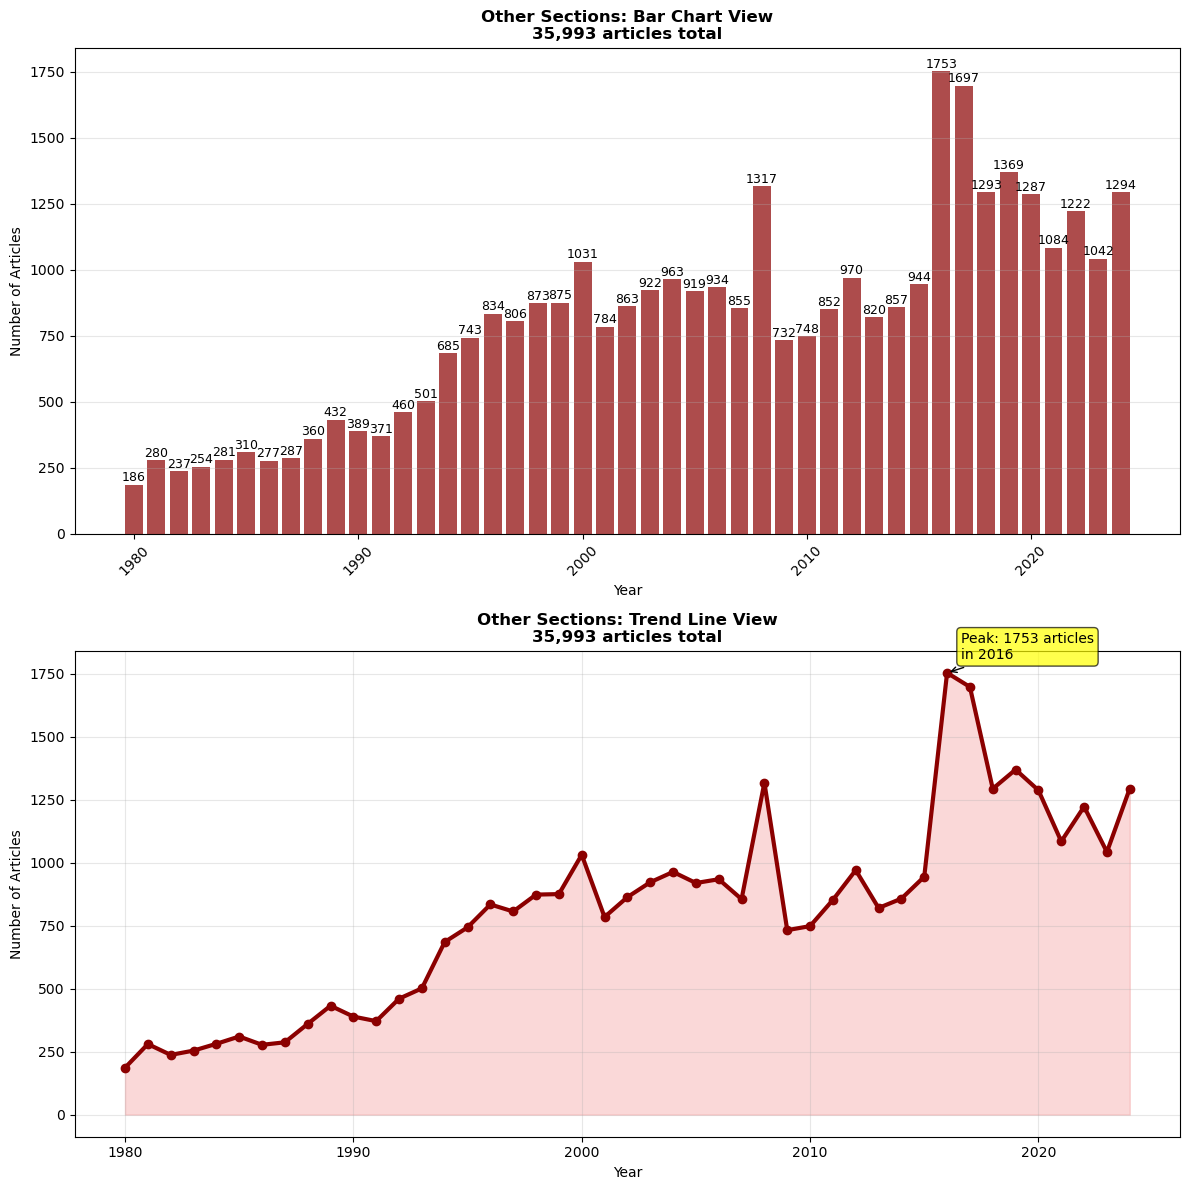

Total articles in 'Other sections': 35,993
Percentage of total dataset: 87.2%
Number of unique 'Other sections': 12389
Years with data: 45
Peak year: 2016 (1753 articles)
Lowest year: 1980 (186 articles)
Average articles per year: 800

Top 10 sections within 'Other sections':
   1. BRIEFING: 198 articles (0.6%)
   2. EDITORIAL,: 183 articles (0.5%)
   3. OPINION; sunday: 183 articles (0.5%)
   4. NEWS; Pg. A1: 176 articles (0.5%)
   5. MAGAZINE: 174 articles (0.5%)
   6. UPSHOT: 164 articles (0.5%)
   7. NEWS; Pg. 0: 162 articles (0.5%)
   8. Section A; Column 0; Foreign Desk; Pg. 1: 158 articles (0.4%)
   9. NATIONAL,: 156 articles (0.4%)
  10. Section C; Column 0; The Arts/Cultural Desk; Pg. 1: 156 articles (0.4%)


In [35]:
# Focus on "Other sections" trend analysis
print(f"\n{'-'*60}")
print("OTHER SECTIONS ANALYSIS (Not in Top 10)")
print(f"{'-'*60}")

# Calculate "Other sections" data (do this once)
top_section_names = set(top_sections.index)
other_sections_data = df_articles[~df_articles['section'].isin(top_section_names)]
other_sections_yearly = other_sections_data['year'].value_counts().sort_index()

# Calculate statistics once
max_year = other_sections_yearly.idxmax()
max_count = other_sections_yearly.max()
min_year = other_sections_yearly.idxmin()
min_count = other_sections_yearly.min()

# Create combined visualization with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# ============================================================================
# 1. BAR CHART
# ============================================================================
bars = ax1.bar(other_sections_yearly.index, other_sections_yearly.values, 
              color='darkred', alpha=0.7, width=0.8)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    if height > 0:
        ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{int(height)}', ha='center', va='bottom', fontsize=9)

ax1.set_title(f'Other Sections: Bar Chart View\n{len(other_sections_data):,} articles total', 
             fontsize=12, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Articles')
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# ============================================================================
# 2. LINE CHART WITH AREA FILL
# ============================================================================
ax2.plot(other_sections_yearly.index, other_sections_yearly.values, 
        marker='o', linewidth=3, color='darkred', markersize=6)
ax2.fill_between(other_sections_yearly.index, other_sections_yearly.values, 
                alpha=0.3, color='lightcoral')

# Add peak annotation
ax2.annotate(f'Peak: {max_count} articles\nin {max_year}', 
            xy=(max_year, max_count), xytext=(10, 10),
            textcoords='offset points', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

ax2.set_title(f'Other Sections: Trend Line View\n{len(other_sections_data):,} articles total', 
             fontsize=12, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Number of Articles')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# SUMMARY STATISTICS (single print section)
# ============================================================================
print(f"Total articles in 'Other sections': {len(other_sections_data):,}")
print(f"Percentage of total dataset: {100*len(other_sections_data)/len(df_articles):.1f}%")
print(f"Number of unique 'Other sections': {other_sections_data['section'].nunique()}")
print(f"Years with data: {len(other_sections_yearly)}")
print(f"Peak year: {max_year} ({max_count} articles)")
print(f"Lowest year: {min_year} ({min_count} articles)")
print(f"Average articles per year: {other_sections_yearly.mean():.0f}")

# Show breakdown of what's in "Other sections"
other_section_breakdown = other_sections_data['section'].value_counts().head(10)
print(f"\nTop 10 sections within 'Other sections':")
for i, (section, count) in enumerate(other_section_breakdown.items(), 1):
    percentage = 100 * count / len(other_sections_data)
    print(f"  {i:2d}. {section}: {count:,} articles ({percentage:.1f}%)")

<a id="length_over_time"></a>
### Average Article Length Over Time


------------------------------------------------------------
ARTICLE LENGTH ANALYSIS OVER TIME
------------------------------------------------------------
Articles with valid word counts: 41,294 (100.0%)
Overall average article length: 1281 words
Median article length: 1058 words
Length range: 91 - 31,014 words


/var/folders/d9/z9bzkbj143b47cv2wkf7c1780000gn/T/ipykernel_6707/2567870747.py:59: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



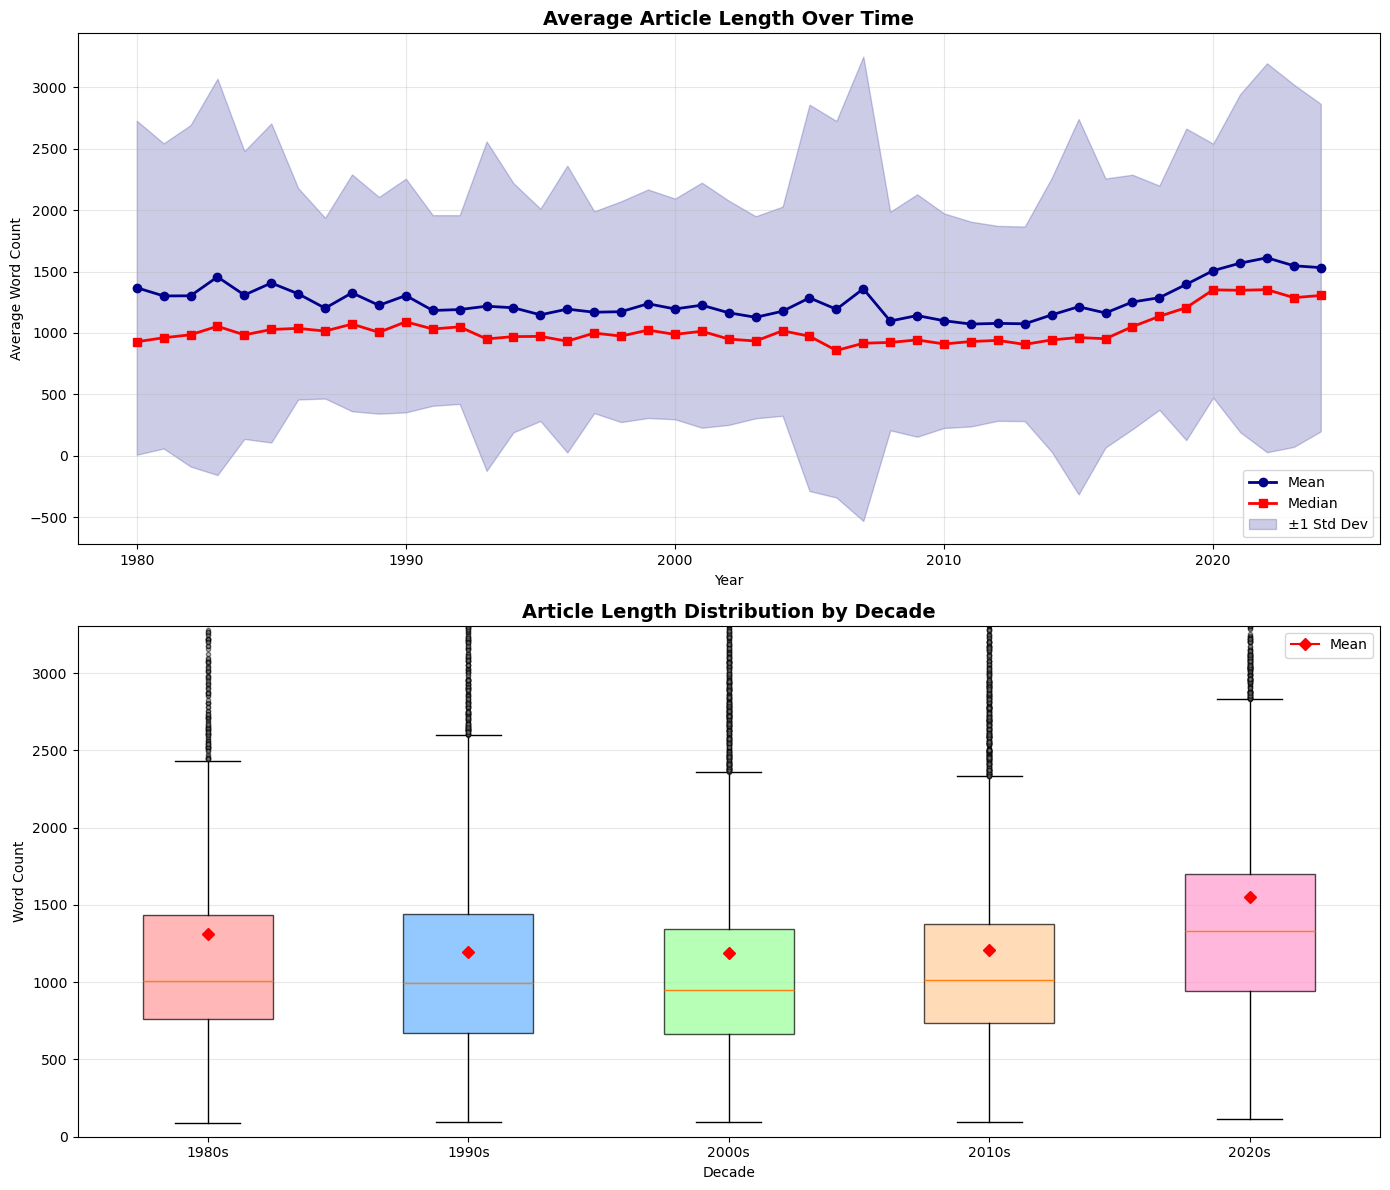


Decade-by-decade breakdown:
  1980s: 2,904 articles, median = 1009 words, mean = 1315 words
  1990s: 6,631 articles, median = 995 words, mean = 1197 words
  2000s: 9,657 articles, median = 950 words, mean = 1191 words
  2010s: 13,444 articles, median = 1015 words, mean = 1207 words
  2020s: 8,658 articles, median = 1332 words, mean = 1551 words


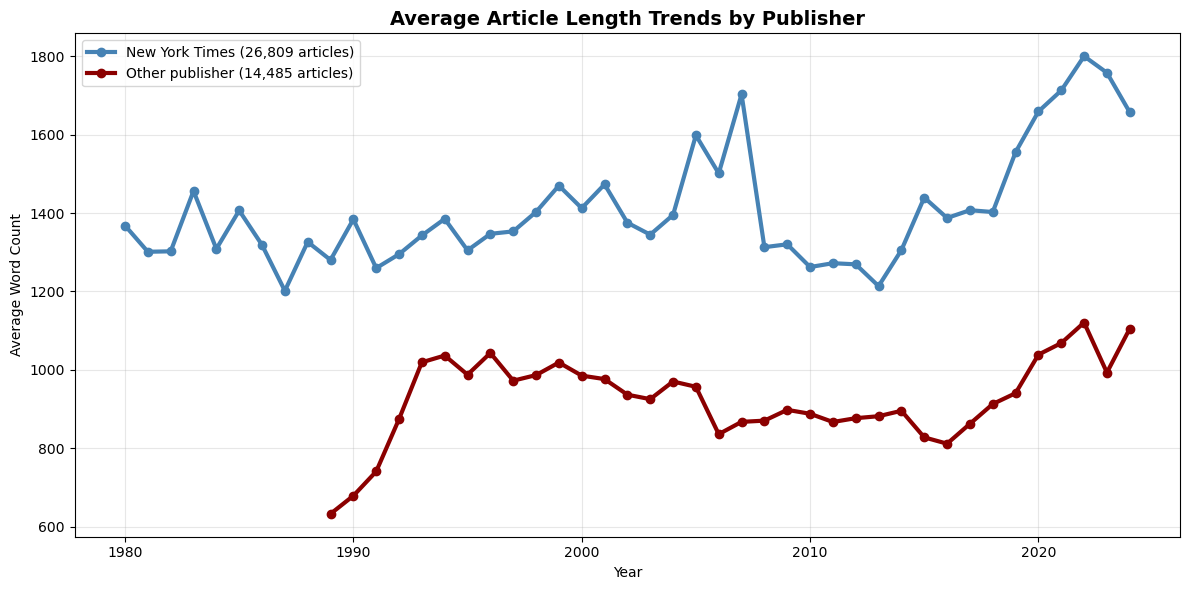


Length comparison by publisher:
  New York Times: 1465 words average, 1210 words median (26,809 articles)
  Other publisher: 941 words average, 807 words median (14,485 articles)


In [42]:
print(f"\n{'-'*60}")
print("ARTICLE LENGTH ANALYSIS OVER TIME")
print(f"{'-'*60}")

df_length_analysis = df_articles[df_articles['word_count'] > 0].copy()
print(f"Articles with valid word counts: {len(df_length_analysis):,} ({100*len(df_length_analysis)/len(df_articles):.1f}%)")
print(f"Overall average article length: {df_length_analysis['word_count'].mean():.0f} words")
print(f"Median article length: {df_length_analysis['word_count'].median():.0f} words")
print(f"Length range: {df_length_analysis['word_count'].min()} - {df_length_analysis['word_count'].max():,} words")

# Calculate yearly statistics
yearly_avg_length = df_length_analysis.groupby('year')['word_count'].agg(['mean', 'median', 'std']).reset_index()

# Create visualizations
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# ============================================================================
# 1. YEARLY TRENDS
# ============================================================================
ax1.plot(yearly_avg_length['year'], yearly_avg_length['mean'], 
         marker='o', linewidth=2, color='darkblue', label='Mean')
ax1.plot(yearly_avg_length['year'], yearly_avg_length['median'], 
         marker='s', linewidth=2, color='red', label='Median')
ax1.fill_between(yearly_avg_length['year'], 
                yearly_avg_length['mean'] - yearly_avg_length['std'],
                yearly_avg_length['mean'] + yearly_avg_length['std'],
                alpha=0.2, color='darkblue', label='±1 Std Dev')

ax1.set_title('Average Article Length Over Time', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Average Word Count')
ax1.legend()
ax1.grid(alpha=0.3)

# ============================================================================
# 2. IMPROVED BOXPLOT BY DECADE
# ============================================================================
df_length_analysis['decade'] = (df_length_analysis['year'] // 10) * 10
decades = sorted(df_length_analysis['decade'].unique())

# Create boxplot with better styling and outlier handling
box_data = []
box_labels = []
decade_stats = []

for decade in decades:
    decade_data = df_length_analysis[df_length_analysis['decade'] == decade]['word_count']
    if len(decade_data) > 0:
        box_data.append(decade_data.values)
        box_labels.append(f"{decade}s")
        decade_stats.append({
            'decade': decade,
            'count': len(decade_data),
            'median': decade_data.median(),
            'mean': decade_data.mean()
        })

# Create boxplot with improved readability
bp = ax2.boxplot(box_data, labels=box_labels, patch_artist=True, 
                 showfliers=True,  # Show outliers but limit them
                 flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.5))

# Color the boxes with a gradient
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC']
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(colors[i % len(colors)])
    patch.set_alpha(0.7)

# Add mean markers
for i, stats in enumerate(decade_stats):
    ax2.plot(i+1, stats['mean'], marker='D', color='red', markersize=6, 
             label='Mean' if i == 0 else "")

ax2.set_title('Article Length Distribution by Decade', fontsize=14, fontweight='bold')
ax2.set_xlabel('Decade')
ax2.set_ylabel('Word Count')
ax2.grid(axis='y', alpha=0.3)
ax2.legend()

# Set y-axis limit to reduce impact of extreme outliers
ax2.set_ylim(0, np.percentile([item for sublist in box_data for item in sublist], 95) * 1.2)

plt.tight_layout()
plt.show()

# Print decade statistics
print(f"\nDecade-by-decade breakdown:")
for stats in decade_stats:
    print(f"  {stats['decade']}s: {stats['count']:,} articles, "
          f"median = {stats['median']:.0f} words, mean = {stats['mean']:.0f} words")

# ============================================================================
# 3. PUBLISHER COMPARISON (Updated for two publishers)
# ============================================================================
plt.figure(figsize=(12, 6))

publishers = ['New York Times', 'Other publisher']
colors = ['steelblue', 'darkred']

for i, publisher in enumerate(publishers):
    publisher_data = df_length_analysis[df_length_analysis['publisher'] == publisher]
    if len(publisher_data) > 0:
        yearly_pub_length = publisher_data.groupby('year')['word_count'].mean()
        plt.plot(yearly_pub_length.index, yearly_pub_length.values, 
                marker='o', linewidth=3, label=f'{publisher} ({len(publisher_data):,} articles)', 
                color=colors[i])

plt.title('Average Article Length Trends by Publisher', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Word Count')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics by publisher
print(f"\nLength comparison by publisher:")
for publisher in publishers:
    pub_data = df_length_analysis[df_length_analysis['publisher'] == publisher]
    if len(pub_data) > 0:
        print(f"  {publisher}: {pub_data['word_count'].mean():.0f} words average, "
              f"{pub_data['word_count'].median():.0f} words median ({len(pub_data):,} articles)")